In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
from time import time
import os

from xpc.xscatter import Material, apply_psf, get_wavelen, get_wavenum

import jax
import jax.numpy as jnp

import chromatix.functional as cx
from chromatix.ops import init_plane_resample

import dataclasses
from typing import Any

import optax
from jaxopt.projection import projection_non_negative
from flax import linen as nn
from flax.core import unfreeze, freeze

In [2]:
# Figure settings

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

def add_scalebar(ax, sz, Nx, real_dx, real_units, color='k', sv=1):
    width_px = sz * Nx 
    label = f'{real_dx * width_px:.0f} {real_units}'
    scalebar = AnchoredSizeBar(ax.transData, width_px, label, 'lower left', size_vertical=sv, frameon=False, color=color)
    ax.add_artist(scalebar)
    
custom_cycler = cycler('color', ['#0072B2', '#009E73', '#F0E442', '#D55E00', '#CC79A7'])  # color-blind friendly

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size':10,
    'axes.titlesize':10,
    'axes.labelsize':8,
    'axes.linewidth': .5,
    'axes.prop_cycle': custom_cycler,
    'xtick.top': True, 
    'ytick.right': True, 
    'xtick.direction': 'in', 
    'ytick.direction': 'in',
    'xtick.labelsize':8,
    'ytick.labelsize':8,
    'legend.fontsize': 8,
    'lines.linewidth':1,
    'image.cmap':'gray',
    'text.usetex': True,
    'font.family': 'serif'
})


In [3]:
# Material definitions 

from xpc.xscatter import nist_mc, calc_mc, victre_matdict

air = Material('air', nist_mc['Air, Dry (near sea level)'], 0.0016)

adip = Material('adipose', nist_mc['Adipose Tissue (ICRU-44)'], 0.95)
gland = Material('gland', nist_mc['Breast Tissue (ICRU-44)'], 1.05)
breast = Material('breast', nist_mc['Breast Tissue (ICRU-44)'], 1.0)
bone = Material('bone', nist_mc['Bone, Cortical (ICRU-44)'], 1.92)
tissue = Material('soft tissue', nist_mc['Tissue, Soft (ICRU-44)'], 1.06)

calc1 = Material('calcification - type I', calc_mc['Calcium Oxalate (Dihydrate)'], 2.0)
calc2 =  Material('calcification - type II', calc_mc['Hydroxyapatite'], 3.1)


In [4]:
# Class helpers

def gaussian_otf(Nx, dx, fwhm):
    fx = jnp.fft.fftfreq(Nx, d=dx)
    fy = jnp.fft.fftfreq(Nx, d=dx)
    FX, FY = jnp.meshgrid(fx, fy, indexing='ij')
    sigma = fwhm / (2 * jnp.sqrt(2 * jnp.log(2)))
    return jnp.exp(-2 * (jnp.pi**2) * sigma**2 * (FX**2 + FY**2))


def downsample_mean(x, factor):
    if factor == 1:
        return x
    Nx = (x.shape[0] // factor) * factor
    Ny = (x.shape[1] // factor) * factor
    x = x[:Nx, :Ny, ...]
    return x.reshape(Nx // factor, factor, Ny // factor, factor, *x.shape[2:]).mean(axis=(1, 3))


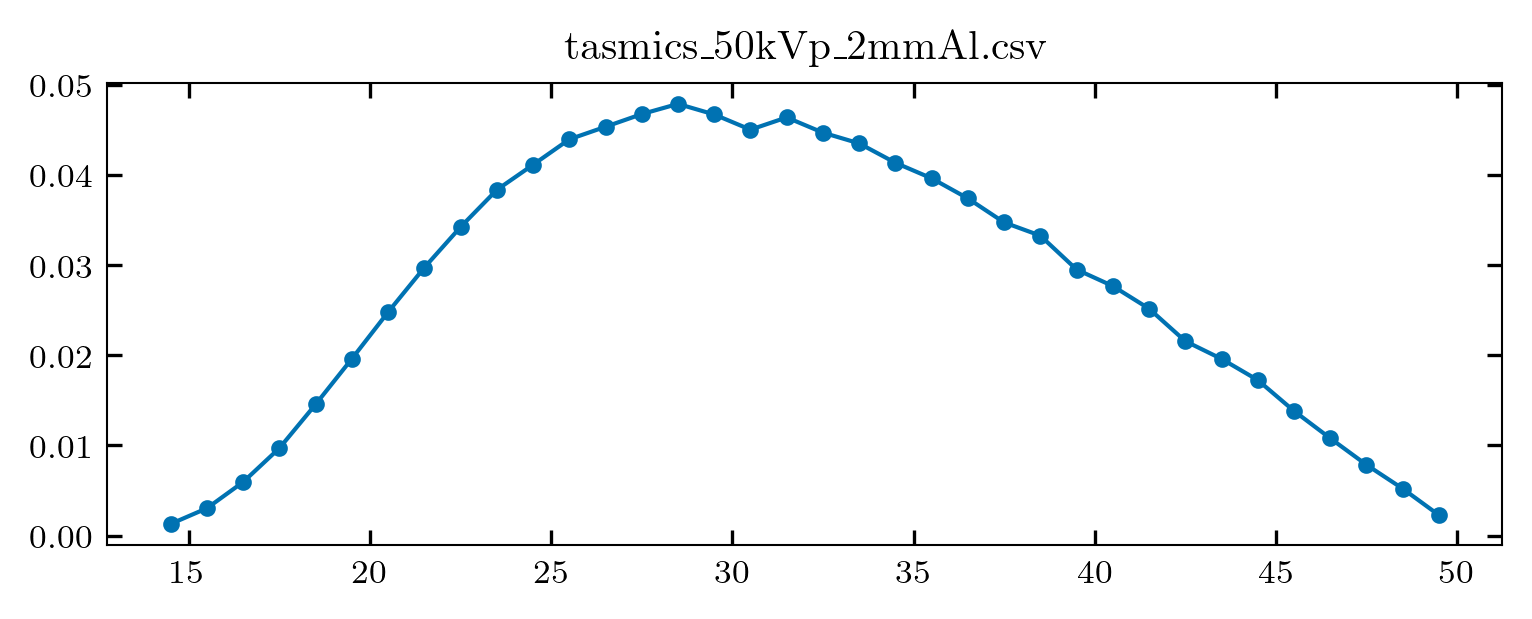

(2, 36)


In [5]:
# Load spectrum
fname = 'tasmics_50kVp_2mmAl.csv'
with open('../inputs/spectrum/'+fname, 'r') as f:
    spectrum = np.array([line.split(',') for line in f.readlines()[1:]], dtype=float).T
    spectrum[1] /= np.sum(spectrum[1])          # normalize total counts
    spectrum = spectrum[:, spectrum[1] > 1e-2 * spectrum[1].max() ]  # remove 0s for speed

# Jax-ify
spectrum = jnp.asarray(spectrum, dtype=jnp.float32)
eta_0 = jnp.ones((1, spectrum.shape[1]), dtype=jnp.float32)

# Show
fig, ax = plt.subplots(1, 1, figsize=[6,2])
ax.set_title(fname)
ax.plot(spectrum[0], spectrum[1], '.-')
plt.show()

print(spectrum.shape)

In [6]:
# Phantom

def rotated_coords(X, Y, x0=0.0, y0=0.0, theta=0.0):
    ct = jnp.cos(theta)
    st = jnp.sin(theta)

    Xc = X - x0
    Yc = Y - y0

    Xr =  ct * Xc + st * Yc
    Yr = -st * Xc + ct * Yc

    return Xr, Yr


def ellipsoid_thickness(X, Y, x0=0.0, y0=0.0, a=0.2, b=0.1, theta=0.0, tmax=1.0):
    Xr, Yr = rotated_coords(X, Y, x0=x0, y0=y0, theta=theta)

    rho2 = (Xr / a)**2 + (Yr / b)**2
    inside = rho2 <= 1.0

    return tmax * jnp.where(inside, jnp.sqrt(jnp.clip(1.0 - rho2, 0.0)), 0.0)


def add_ellipsoids(X, Y, ellipsoids):
    tmap = jnp.zeros_like(X)

    for e in ellipsoids:
        tmap = tmap + ellipsoid_thickness(X, Y, **e)

    return tmap

# Phantom

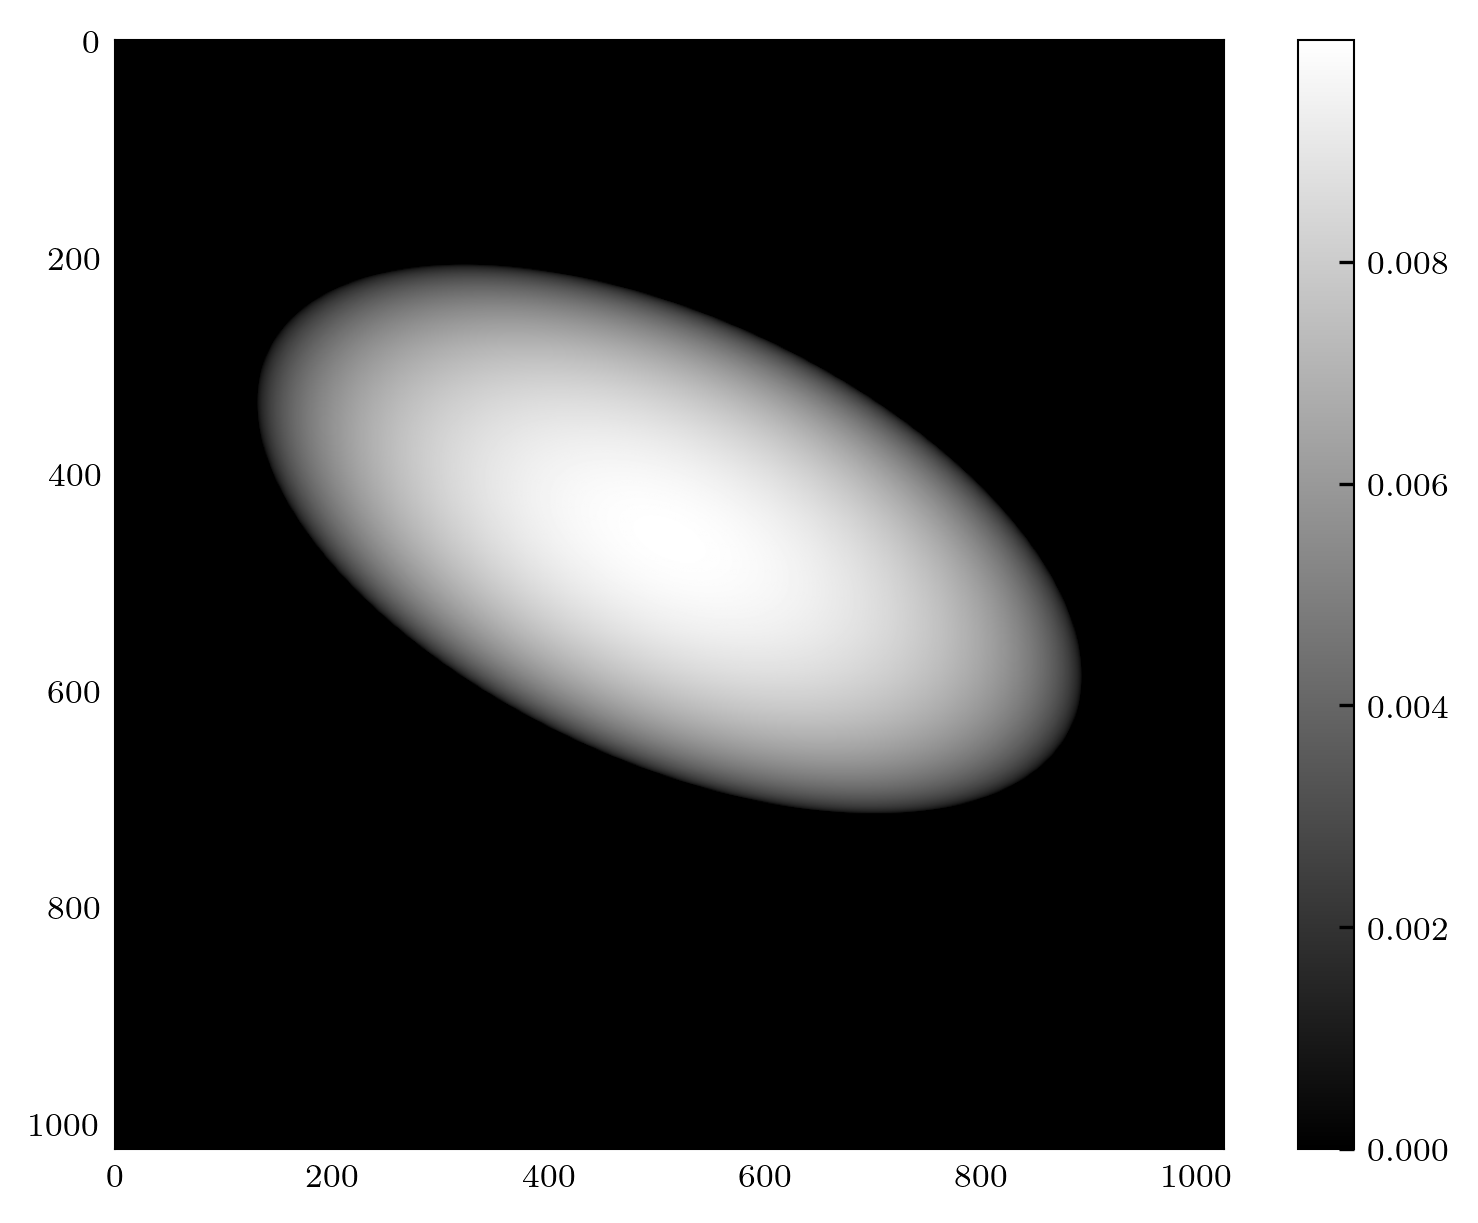

In [7]:
x = jnp.linspace(-1, 1, 1024) #model.Nx)
X, Y = jnp.meshgrid(x, x, indexing='xy')

ellipsoids = [
    dict(x0=0.0,  y0=-0.1,  a=0.8, b=0.4, theta=np.deg2rad(25),  tmax=1e-2),
    # dict(x0=0.25, y0=0.15, a=0.18, b=0.06, theta=np.deg2rad(-35), tmax=4e-3),
    # dict(x0=-0.3, y0=-0.2, a=0.12, b=0.08, theta=np.deg2rad(70),  tmax=6e-3),
]

tmap = add_ellipsoids(X, Y, ellipsoids)

plt.imshow(tmap)
plt.colorbar()
plt.show()

# Simulation class

In [8]:
class SpectralPBI(nn.Module):

    propdist: float = 60e-2
    I0_total: float = 1000.0

    dx: float = 10e-6 / 8
    Nx: int = 1024

    mats: Any = dataclasses.field(default_factory=lambda: (tissue,))
    init_tmap: Any = None

    upsample_factor: int = 8
    N_pad: int = 0
    n_medium: float = 1.0

    spectrum: Any = None
    etas: Any = None

    psf_fwhm: float | None = 10e-6
    return_energy_resolved: bool = False

    def setup(self):
        if self.spectrum is None:
            raise ValueError('spectrum must have shape [2, Ne].')
        if self.etas is None:
            raise ValueError('etas must have shape [Ne] or [N_bins, Ne].')

        B = len(self.mats)

        if self.init_tmap is None:
            tmap_init = lambda key, shape: jnp.full(shape, 1e-9, dtype=jnp.float32)
        else:
            init_tmap = jnp.asarray(self.init_tmap, dtype=jnp.float32)
            if init_tmap.shape != (B, self.Nx, self.Nx):
                raise ValueError(f'init_tmap must have shape {(B, self.Nx, self.Nx)}.')
            tmap_init = lambda key, shape: init_tmap

        self.tmap = self.param(
            'tmap',
            tmap_init,
            (B, self.Nx, self.Nx),
        )

        spectrum = jnp.asarray(self.spectrum, dtype=jnp.float32)
        etas = jnp.asarray(self.etas, dtype=jnp.float32)

        if etas.ndim == 1:
            etas = etas[None, :]

        energies = spectrum[0]
        counts = spectrum[1]
        weights = counts / jnp.sum(counts)

        self.energies = energies
        self.I0s = self.I0_total * weights
        self.etas_arr = etas
        self.flat_bins = jnp.einsum('ce,e->c', self.etas_arr, self.I0s)

        dbs = [m.delta_beta_jnp(energies) for m in self.mats]
        self.ds = jnp.stack([d for d, _ in dbs], axis=0).astype(jnp.float32)
        self.bs = jnp.stack([b for _, b in dbs], axis=0).astype(jnp.float32)

        self.wavelens = get_wavelen(self.energies) / self.n_medium
        self.ks = 2 * jnp.pi / self.wavelens

        N_prop = self.Nx + 2 * self.N_pad

        fx = jnp.fft.fftfreq(N_prop, d=self.dx)
        fy = jnp.fft.fftfreq(N_prop, d=self.dx)
        FX, FY = jnp.meshgrid(fx, fy, indexing='ij')
        f2 = FX**2 + FY**2

        self.H = jnp.exp(
            -1j * jnp.pi * self.wavelens[None, None, :] * self.propdist * f2[:, :, None]
        ).astype(jnp.complex64)

        if self.psf_fwhm is None or self.psf_fwhm <= 0:
            self.psf_otf = None
        else:
            self.psf_otf = gaussian_otf(self.Nx, self.dx, self.psf_fwhm).astype(jnp.float32)

    def propagate(self, u):
        if self.N_pad > 0:
            u = jnp.pad(
                u,
                ((self.N_pad, self.N_pad), (self.N_pad, self.N_pad), (0, 0)),
                mode='constant',
                constant_values=1.0 + 0.0j,
            )

        u = jnp.fft.ifft2(
            jnp.fft.fft2(u, axes=(0, 1)) * self.H,
            axes=(0, 1),
        )

        if self.N_pad > 0:
            u = u[self.N_pad:-self.N_pad, self.N_pad:-self.N_pad, :]

        return u

    def apply_psf(self, imgs):
        if self.psf_otf is None:
            return imgs

        return jnp.fft.ifft2(
            jnp.fft.fft2(imgs, axes=(0, 1)) * self.psf_otf[:, :, None],
            axes=(0, 1),
        ).real

    def __call__(self):
        delta_proj = jnp.einsum('bxy,be->xye', self.tmap, self.ds)
        beta_proj = jnp.einsum('bxy,be->xye', self.tmap, self.bs)

        exit_field = jnp.exp(
            -self.ks[None, None, :] * beta_proj
            -1j * self.ks[None, None, :] * delta_proj
        ).astype(jnp.complex64)

        imgs_E = jnp.abs(self.propagate(exit_field))**2

        if self.return_energy_resolved:
            imgs_E = self.apply_psf(imgs_E)
            imgs_E = downsample_mean(imgs_E, self.upsample_factor)
            return imgs_E.clip(0, None)

        bin_imgs = jnp.einsum('ce,xye,e->xyc', self.etas_arr, imgs_E, self.I0s)
        bin_imgs = bin_imgs / (self.flat_bins[None, None, :] + 1e-12)

        bin_imgs = self.apply_psf(bin_imgs)
        bin_imgs = downsample_mean(bin_imgs, self.upsample_factor)

        return bin_imgs.clip(0, None)

In [9]:
model = SpectralPBI(
    mats=(tissue,),
    spectrum=spectrum,
    etas=eta_0,
    init_tmap=tmap[None, :, :],
)

key = jax.random.PRNGKey(3)
params = model.init(key)

fwd = jax.jit(lambda params: model.apply(params))

data = fwd(params).block_until_ready()

%timeit fwd(params).block_until_ready()

488 ms ± 102 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


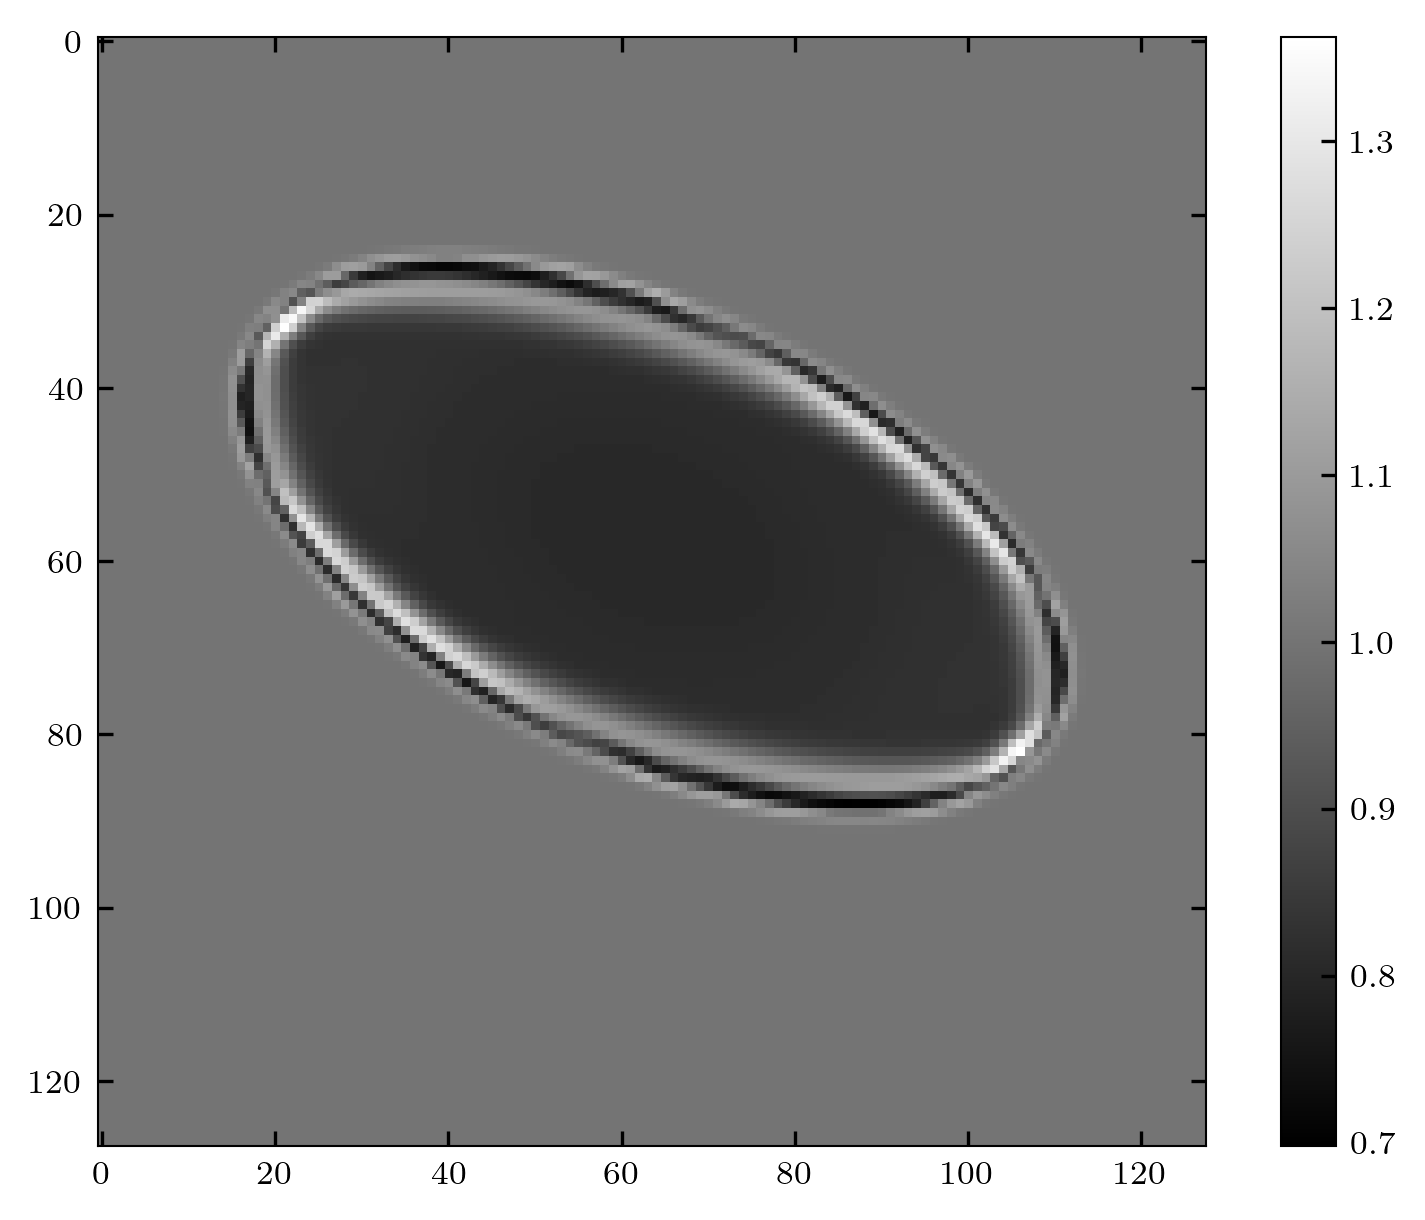

In [11]:
plt.imshow(data[:,:,0])
plt.colorbar()
plt.show()